In [2]:

def reduce_size(input_input, window_size_tup, stride_tup):
    pass

reduce_size('img_200x200.jpg',(3, 3), (2, 2)) #Output size: 100x100

reduce_size('img_200x200.jpg',(4, 4), (2, 2)) #Output size: 100x100

reduce_size('img_200x200.jpg',(4, 4), (1, 1)) #Output size: 200x200

reduce_size('img_200x200.jpg',(4, 4), (4, 4)) #Output size: 50x50




In [3]:

def conv(input_input, kernel, stride_tup):
    pass


conv('img_200x200.jpg', [[1, 0], [0, 0]], (2, 2)) # reduces the size of image by half and picks only left top pixel from each window/receptive field

conv('img_200x200.jpg', [[0, 0, 0], [0, 1, 0], [0, 0, 0]], (2, 2)) # output: half size and picks the center of the image 

conv('img_200x200.jpg', [[0.25, .25], [.25, .25]], (2, 2)) # Average

conv('img_200x200.jpg', [[1, 1], [1, 1]], (2, 2)) # Sum



In [12]:
# https://chatgpt.com/share/69ff55f6-f9ac-83e8-88c5-0b6a147eec19

In [4]:
!pip install librosa matplotlib numpy soundfile


zsh:1: /Users/sandeepgiri/projects/course_repos/june_2025_iitr/.venv/bin/pip: bad interpreter: /Users/sandeepgiri/projects/june_2025_iitr/.venv/bin/python3.12: no such file or directory

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: /Users/sandeepgiri/miniconda3/bin/python -m pip install --upgrade pip


/Users/sandeepgiri/projects/course_repos/june_2025_iitr/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


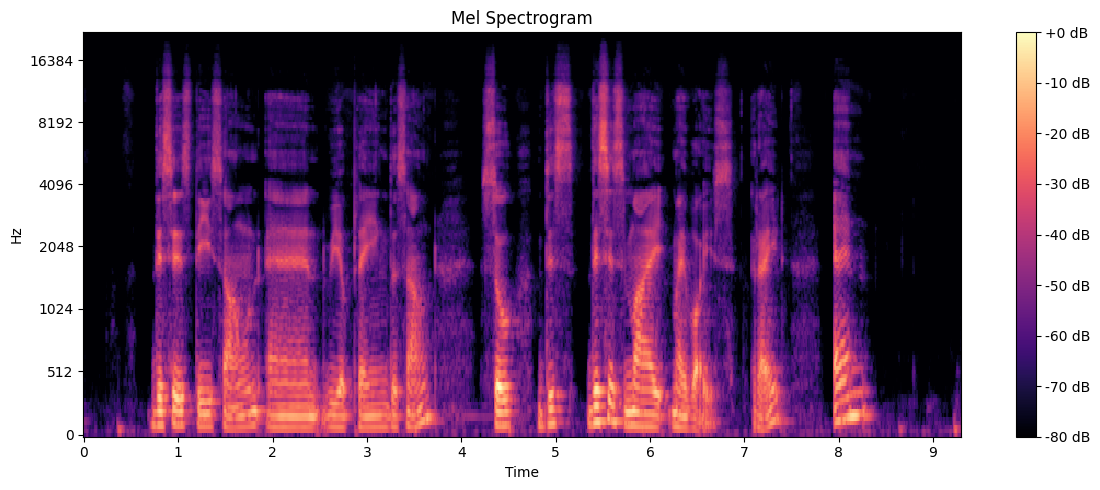

In [9]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Path to your WAV file
wav_path = "cnn_audio.wav"

# Load audio
y, sr = librosa.load(wav_path, sr=None)

# Create Mel spectrogram
mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_fft=2048,
    hop_length=512,
    n_mels=128
)

# Convert power spectrogram to dB scale
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

# Display
plt.figure(figsize=(12, 5))
librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()

In [10]:
import librosa
import soundfile as sf
import numpy as np

# Suppose mel_spec_db is your mel spectrogram in dB
# Shape: (n_mels, time_frames)

# Convert dB -> power
mel_power = librosa.db_to_power(mel_spec_db)

# Mel -> linear spectrogram
linear_spec = librosa.feature.inverse.mel_to_stft(
    mel_power,
    sr=sr,
    n_fft=2048
)

# Spectrogram -> waveform using Griffin-Lim
audio = librosa.griffinlim(
    linear_spec,
    hop_length=512
)

# Save as wav
sf.write("reconstructed.wav", audio, sr)

print("Saved reconstructed.wav")

Saved reconstructed.wav


In [15]:
import tensorflow as tf
import matplotlib.pyplot as plt


In [44]:
# Load image
img_path = "pexels-cmrcn-27799203.jpg"

img = tf.io.read_file(img_path)
img = tf.image.decode_image(img, channels=3)
img = tf.image.convert_image_dtype(img, tf.float32)



In [45]:
img.shape

TensorShape([6240, 3510, 3])

In [19]:
img_batch = tf.expand_dims(img, axis=0)

gray = tf.image.rgb_to_grayscale(img_batch)


In [46]:
img_batch.shape

TensorShape([1, 6240, 3510, 3])

In [47]:
gray.shape

TensorShape([1, 6240, 3510, 1])

In [82]:
# Example: edge detection filter
# Kernel 1: averaging / blur
k1 = [
    [[0.1, 0.1, 0.1], [0.1, 0.1, 0.1], [0.1, 0.1, 0.1]],
    [[0.1, 0.1, 0.1], [0.1, 0.1, 0.1], [0.1, 0.1, 0.1]],
    [[0.1, 0.1, 0.1], [0.1, 0.1, 0.1], [0.1, 0.1, 0.1]],
]

# Kernel 2: vertical detector
k2 = [
    [[0, 0.3, 0], [0, 0.3, 0], [0, 0.4, 0]],
    [[0, 0.3, 0], [0, 0.3, 0], [0, 0.4, 0]],
    [[0, 0.3, 0], [0, 0.3, 0], [0, 0.4, 0]],
]

k3 = [
    [[1, 0, 0], [0, 0, 0], [0, 0, 0]],
    [[0, 0, 0], [0, 0, 0], [0, 0, 0]],
    [[0, 0, 0], [0, 0, 0], [0, 0, 0]],
]
# Stack into [3,3,3,2]
kernel = tf.stack([k1, k2, k3], axis=-1)
kernel = tf.constant(kernel, dtype=tf.float32)

print(kernel.shape)   # (3, 3, 3, 2)

# Shape required by tf.nn.conv2d:
# [filter_height, filter_width, input_channels, output_channels]
# kernel = tf.reshape(kernels, [3, 3, 1, 1])

# Convert RGB image to grayscale
# gray = tf.image.rgb_to_grayscale(img_batch)


(3, 3, 3, 3)


In [83]:
gray.shape

TensorShape([1, 6240, 3510, 1])

In [84]:
img_batch.shape

TensorShape([1, 6240, 3510, 3])

In [85]:
kernel.shape

TensorShape([3, 3, 3, 3])

In [86]:
output = tf.nn.conv2d(
    img_batch,
    kernel,
    strides=2,
    padding="SAME"
)


In [87]:
output.shape

TensorShape([1, 3120, 1755, 3])

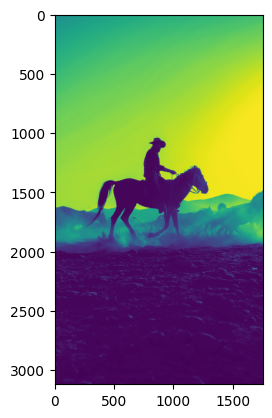

In [79]:
plt.imshow(output[0, :, :, 0])

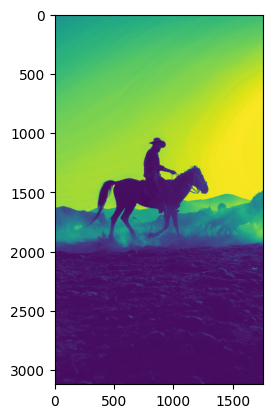

In [88]:
plt.imshow(output[0, :, :, 1])

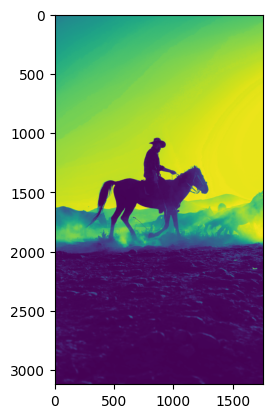

In [89]:
plt.imshow(output[0, :, :, 2])

In [30]:
output_img = tf.squeeze(output)


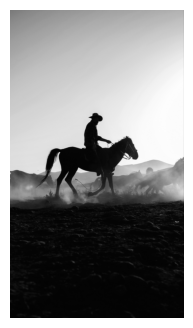

In [32]:
# Display original and filtered image
plt.figure(figsize=(10, 4))

plt.imshow(output_img, cmap="gray")
plt.axis("off")

plt.show()

In [91]:
# https://chatgpt.com/share/69ff5ce4-8118-83ec-b211-588e2b647a0d
# Create a kernel 7x7 - grayscale
# Try different kernels that look like vertical lines, horizontal lines etc 

# The following is vertical line.
[0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0],

# Observe the output

# Also try highlighting different colors by choosing the kernels wisely


([0, 0, 0, 1, 0, 0, 0],)

In [ ]:
Account 1 - 12477
ICICI Bank - 96172.82
Account 2 - ₹41,122.82

